# 04 · Time series: trends, AR models, unit roots, seasonality, ARCH, cointegration

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lukasquaderer-lgtm/Linear-regression/blob/master/notebooks/04_time_series.ipynb)

**Goal:** walk the full CFA time-series workflow on quarterly data.

Columns in `macro_quarterly.csv`: `retail_sales` (growing, seasonal), `inflation` (mean-reverting),
`fx_rate` (random walk), `index_return` (volatility clusters), `oil_price`, `energy_stock`, `gold_price` (for cointegration).

In [1]:
# Setup: run this cell first (Shift + Enter). Works in Jupyter, VS Code and Google Colab.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # hide library deprecation notices

# Use the local data folder if it exists, otherwise read the CSVs straight from GitHub (e.g. in Colab)
DATA = "../data/" if Path("../data").exists() else "https://raw.githubusercontent.com/lukasquaderer-lgtm/Linear-regression/master/data/"
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (8, 4)
print("Ready. Data folder:", DATA)

Ready. Data folder: ../data/


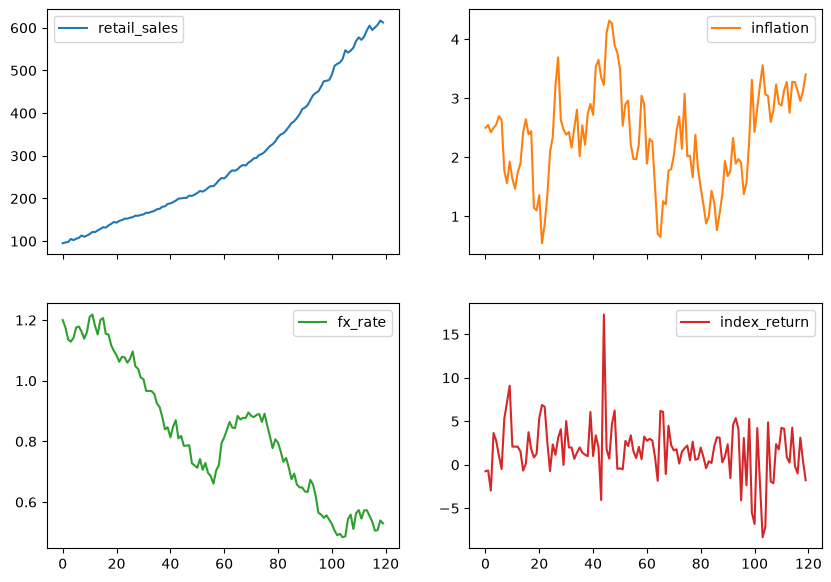

In [2]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller, coint, acf
from statsmodels.stats.diagnostic import het_arch

ts = pd.read_csv(DATA + "macro_quarterly.csv")
T = len(ts)
ts[["retail_sales", "inflation", "fx_rate", "index_return"]].plot(subplots=True, figsize=(10, 7), layout=(2, 2)); plt.show()

## 1. Trend models: linear vs log-linear for retail sales

In [3]:
t = sm.add_constant(ts["t"])
lin = sm.OLS(ts["retail_sales"], t).fit()
loglin = sm.OLS(np.log(ts["retail_sales"]), t).fit()
print(f"Linear:     b1 = {lin.params['t']:.3f} per quarter, DW = {durbin_watson(lin.resid):.2f}")
print(f"Log-linear: b1 = {loglin.params['t']:.4f} → growth ≈ {100*(np.exp(loglin.params['t'])-1):.2f}% per quarter, DW = {durbin_watson(loglin.resid):.2f}")
# forecast next quarter from the log-linear model: remember to exponentiate
print("Log-linear forecast for t = 121:", round(np.exp(loglin.params["const"] + loglin.params["t"] * 121), 2))

Linear:     b1 = 4.354 per quarter, DW = 0.01
Log-linear: b1 = 0.0156 → growth ≈ 1.57% per quarter, DW = 0.21
Log-linear forecast for t = 121: 652.39


DW far from 2 → the residuals are serially correlated → a trend model alone is misspecified.

## 2. AR(1) model for inflation
Regress $x_t$ on $x_{t-1}$; the mean-reverting level is $b_0/(1-b_1)$.

In [4]:
x = ts["inflation"]
d = pd.DataFrame({"x": x, "x_lag1": x.shift(1)}).dropna()
ar1 = sm.OLS(d["x"], sm.add_constant(d["x_lag1"])).fit()
b0, b1 = ar1.params
print(ar1.summary().tables[1])
print(f"Mean-reverting level = {b0/(1-b1):.3f}; last value = {x.iloc[-1]:.3f}")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3751      0.126      2.974      0.004       0.125       0.625
x_lag1         0.8427      0.051     16.535      0.000       0.742       0.944
Mean-reverting level = 2.384; last value = 3.406


### Check residual autocorrelations: t = ρ / (1/√T)

In [5]:
r = acf(ar1.resid, nlags=8, fft=False)[1:]
Tn = len(ar1.resid)
pd.DataFrame({"lag": range(1, 9), "autocorr": r, "t_stat": r / (1 / np.sqrt(Tn))}).round(3).set_index("lag")

,autocorr,t_stat
lag,,
1,-0.010,-0.105
2,-0.034,-0.375
3,0.073,0.791
4,0.103,1.121
5,-0.077,-0.841
6,-0.108,-1.177
7,-0.011,-0.123
8,-0.100,-1.090


No |t| above ~2 → AR(1) is correctly specified. (Test many lags and about 1 in 20 can look significant by chance.) Now forecast with the **chain rule**:

In [6]:
f1 = b0 + b1 * x.iloc[-1]; f2 = b0 + b1 * f1
print(f"one step ahead: {f1:.3f}, two steps ahead: {f2:.3f}")

one step ahead: 3.245, two steps ahead: 3.110


### Out-of-sample comparison: AR(1) vs AR(2) by RMSE
Fit on the first 100 quarters, forecast the last 20 one step at a time.

In [7]:
def oos_rmse(p, split=100):
    lags = pd.concat({f"l{i}": x.shift(i) for i in range(1, p + 1)}, axis=1)
    dd = pd.concat([x.rename("x"), lags], axis=1).dropna()
    train, test = dd[dd.index < split], dd[dd.index >= split]
    fit = sm.OLS(train["x"], sm.add_constant(train.drop(columns="x"))).fit()
    pred = fit.predict(sm.add_constant(test.drop(columns="x"), has_constant="add"))
    return np.sqrt(((test["x"] - pred) ** 2).mean())
print("RMSE AR(1):", round(oos_rmse(1), 4), "| RMSE AR(2):", round(oos_rmse(2), 4))

RMSE AR(1): 0.37 | RMSE AR(2): 0.3801


## 3. Random walk and the Dickey–Fuller test on the exchange rate
H₀: unit root (g₁ = 0). `adfuller` with `maxlag=0` is the plain DF test.

In [8]:
stat, p, *_ = adfuller(ts["fx_rate"], maxlag=0, autolag=None, regression="c")
print(f"Levels: DF t = {stat:.2f}, p = {p:.3f} → {'unit root, cannot reject' if p > 0.05 else 'stationary'}")
dfx = ts["fx_rate"].diff().dropna()
stat, p, *_ = adfuller(dfx, maxlag=0, autolag=None, regression="c")
print(f"First difference: DF t = {stat:.2f}, p = {p:.4f} → {'stationary' if p < 0.05 else 'still unit root'}")

Levels: DF t = -1.08, p = 0.722 → unit root, cannot reject
First difference: DF t = -10.73, p = 0.0000 → stationary


In [9]:
# The same test by hand: regress Δx_t on x_{t-1}
dd = pd.DataFrame({"dx": ts["fx_rate"].diff(), "lag": ts["fx_rate"].shift(1)}).dropna()
dfm = sm.OLS(dd["dx"], sm.add_constant(dd["lag"])).fit()
print("g1 =", round(dfm.params["lag"], 4), "t =", round(dfm.tvalues["lag"], 2), "(compare with DF critical ≈ -2.89, not -1.96)")

g1 = -0.0122 t = -1.08 (compare with DF critical ≈ -2.89, not -1.96)


## 4. Seasonality
Model quarterly growth in (log) retail sales, check residual autocorrelation at lag 4, then add the seasonal lag.

In [10]:
g = np.log(ts["retail_sales"]).diff()
d = pd.DataFrame({"g": g, "l1": g.shift(1), "l4": g.shift(4)}).dropna()
m1 = sm.OLS(d["g"], sm.add_constant(d[["l1"]])).fit()
r = acf(m1.resid, nlags=6, fft=False)[1:]
print("Residual autocorr t-stats, AR(1):", np.round(r * np.sqrt(len(d)), 2))
m4 = sm.OLS(d["g"], sm.add_constant(d[["l1", "l4"]])).fit()
r = acf(m4.resid, nlags=6, fft=False)[1:]
print("Residual autocorr t-stats, AR(1)+lag 4:", np.round(r * np.sqrt(len(d)), 2))
print(m4.params.round(4))

Residual autocorr t-stats, AR(1): [-0.3  -2.42 -0.58  7.65 -0.59 -2.49]
Residual autocorr t-stats, AR(1)+lag 4: [ 0.29 -0.1  -0.56 -0.45  0.71 -1.2 ]
const    0.0046
l1      -0.0497
l4       0.7374
dtype: float64


## 5. ARCH: does volatility cluster in index returns?
Regress ε̂²ₜ on ε̂²ₜ₋₁; a significant slope means ARCH(1).

In [11]:
e = ts["index_return"] - ts["index_return"].mean()
e2 = pd.DataFrame({"e2": e ** 2, "e2_lag": (e ** 2).shift(1)}).dropna()
arch = sm.OLS(e2["e2"], sm.add_constant(e2["e2_lag"])).fit()
a0, a1 = arch.params
print(f"a1 = {a1:.3f}, t = {arch.tvalues['e2_lag']:.2f}")
print(f"Next-quarter variance forecast = a0 + a1·e_T² = {a0 + a1 * e.iloc[-1]**2:.2f}")
print("statsmodels het_arch p-value:", round(het_arch(e, nlags=1)[1], 4))

a1 = 0.203, t = 2.25
Next-quarter variance forecast = a0 + a1·e_T² = 10.54
statsmodels het_arch p-value: 0.0265


## 6. Two series with unit roots: cointegration (Engle–Granger)

In [12]:
for a, b in [("energy_stock", "oil_price"), ("gold_price", "oil_price")]:
    t_stat, p, _ = coint(ts[a], ts[b])
    print(f"{a} vs {b}: EG t = {t_stat:.2f}, p = {p:.3f} → {'cointegrated: regression valid' if p < 0.05 else 'NOT cointegrated: regression spurious'}")

energy_stock vs oil_price: EG t = -8.98, p = 0.000 → cointegrated: regression valid
gold_price vs oil_price: EG t = -2.07, p = 0.490 → NOT cointegrated: regression spurious


### Exercise 1

Run the Dickey–Fuller test on `inflation` in levels. Do you reject the unit root? Is that consistent with the AR(1) estimate b₁?

In [13]:
# Your code here

### Exercise 2

Fit an AR(1) to the first-differenced `fx_rate`. Is b₁ significant? What does that say about predicting exchange-rate changes?

In [14]:
# Your code here

### Exercise 3

Forecast inflation **four** quarters ahead with the chain rule. Which value does the forecast approach as the horizon grows?

In [15]:
# Your code here

### Exercise 4

Regress `gold_price` on `oil_price` with OLS and look at R² and the t-stat. Why should you not trust them?

In [16]:
# Your code here

---
## Solutions

In [17]:
s, p, *_ = adfuller(ts["inflation"], maxlag=0, autolag=None); print(f"1) DF t={s:.2f}, p={p:.4f}; b1={b1:.3f} < 1 → stationary")
dd = pd.DataFrame({"y": dfx, "l": dfx.shift(1)}).dropna(); r2 = sm.OLS(dd["y"], sm.add_constant(dd["l"])).fit()
print(f"2) b1={r2.params['l']:.3f}, p={r2.pvalues['l']:.3f} →", "changes are not predictable (random walk)" if r2.pvalues["l"] > 0.05 else "some predictability")
f = x.iloc[-1]
for h in range(1, 5):
    f = b0 + b1 * f; print(f"3) h={h}: {f:.3f}")
print("   → converges to the mean-reverting level", round(b0 / (1 - b1), 3))
sp = sm.OLS(ts["gold_price"], sm.add_constant(ts["oil_price"])).fit()
print(f"4) R2={sp.rsquared:.2f}, t={sp.tvalues['oil_price']:.1f}: both unit-root, not cointegrated → spurious regression")

1) DF t=-3.09, p=0.0275; b1=0.843 < 1 → stationary
2) b1=0.006, p=0.949 → changes are not predictable (random walk)
3) h=1: 3.245
3) h=2: 3.110
3) h=3: 2.996
3) h=4: 2.900
   → converges to the mean-reverting level 2.384
4) R2=0.09, t=3.5: both unit-root, not cointegrated → spurious regression
